# Full Retail Dataset Properties - Student Notebook

## Learning outcomes

By the end of this session, you should be able to:

1. load related CSV files into pandas;
2. distinguish pandas storage dtypes from semantic data types;
3. profile missingness, uniqueness, duplicates and invalid values;
4. clean a copy of a dataset without changing the raw data;
5. summarise categorical, numeric and time-based variables;
6. join related tables into one modelling table;
7. prepare simple machine-learning features from a transactional dataset.

Write code only in cells marked **TASK**.


## Core concepts

A pandas **dtype** describes how a value is stored, for example `int64`, `float64`, `object` or `datetime64`.

A **semantic type** describes what the value means:

- identifier: a label such as `Item Code`;
- nominal category: unordered groups such as `Category Name`;
- binary category: two states such as discount yes/no;
- ratio numeric: values with a meaningful zero, such as kilos or price;
- temporal: dates and times.

This dataset contains four related tables:

- `items.csv`: item names and categories;
- `loss_rates.csv`: item-level waste/loss percentage;
- `sales.csv`: individual sale and return transactions;
- `wholesale_prices.csv`: daily item purchase prices.


## Environment


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_DIR = Path('.')
if not (DATA_DIR / 'sales.csv').exists():
    DATA_DIR = Path('full-dataset-example')

FILES = {
    'items': DATA_DIR / 'items.csv',
    'loss_rates': DATA_DIR / 'loss_rates.csv',
    'sales': DATA_DIR / 'sales.csv',
    'wholesale_prices': DATA_DIR / 'wholesale_prices.csv',
}

FILES


{'items': PosixPath('items.csv'),
 'loss_rates': PosixPath('loss_rates.csv'),
 'sales': PosixPath('sales.csv'),
 'wholesale_prices': PosixPath('wholesale_prices.csv')}

### TASK 1 - Load the datasets

Load the four CSV files. Parse `Date` columns as dates. Combine `Date` and `Time` in `sales.csv` into a new `Timestamp` column. Print the shape of each table.


In [2]:
items = pd.read_csv(FILES['items'])
loss_rates = pd.read_csv(FILES['loss_rates'])
sales = pd.read_csv(FILES['sales'], parse_dates=['Date'])
wholesale_prices = pd.read_csv(FILES['wholesale_prices'], parse_dates=['Date'])

# TODO: create sales['Timestamp']
sales['Timestamp'] = pd.to_datetime(sales['Date'].dt.strftime('%Y-%m-%d') + ' ' + sales['Time'],
                                    errors='coerce')

# TODO: print table shapes
shapes = pd.DataFrame({
    'table': ['items', 'loss_rates', 'sales', 'wholesale_prices'],
    'rows': [len(items), len(loss_rates), len(sales), len(wholesale_prices)],
    'columns': [items.shape[1], loss_rates.shape[1], sales.shape[1], wholesale_prices.shape[1]],
})
display(shapes)

,table,rows,columns
0,items,251,7
1,loss_rates,251,4
2,sales,878503,8
3,wholesale_prices,55982,3


### TASK 2 - First inspection

Display the first five rows of each table and inspect storage dtypes with `.info()`.


In [3]:
# TODO First inspection of the tables
for name, df in {
    'items': items,
    'loss_rates': loss_rates,
    'sales': sales,
    'wholesale_prices': wholesale_prices,
}.items():
    print(f"<---------- Table: {name} ({df.shape[0]} rows, {df.shape[1]} columns) ---------->")
    display(df.info())
    display(df.head())

<---------- Table: items (251 rows, 7 columns) ---------->
<class 'pandas.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Item Code               251 non-null    int64
 1   Item Name               251 non-null    str  
 2   Category Code           251 non-null    str  
 3   Category Name           251 non-null    str  
 4   Original Item Name      251 non-null    str  
 5   Original Category Code  251 non-null    int64
 6   Original Category Name  251 non-null    str  
dtypes: int64(2), str(5)
memory usage: 13.9 KB


None

,Item Code,Item Name,Category Code,Category Name,Original Item Name,Original Category Code,Original Category Name
0,102900005115168,Standard Romaine Lettuce (Loose),EU01,Leafy Greens,Niushou Shengcai,1011010101,Flower/Leaf Vegetables
1,102900005115199,Standard Butterhead Lettuce (500g pack),EU01,Leafy Greens,Sichuan Red Cedar,1011010101,Flower/Leaf Vegetables
2,102900005115625,Standard Baby Spinach (1kg pack),EU01,Leafy Greens,Local Xiaomao Cabbage,1011010101,Flower/Leaf Vegetables
3,102900005115748,Standard Rocket (Bunch),EU01,Leafy Greens,White Caitai,1011010101,Flower/Leaf Vegetables
4,102900005115762,Standard Swiss Chard (Punnet),EU01,Leafy Greens,Amaranth,1011010101,Flower/Leaf Vegetables


<---------- Table: loss_rates (251 rows, 4 columns) ---------->
<class 'pandas.DataFrame'>
RangeIndex: 251 entries, 0 to 250
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Item Code           251 non-null    int64  
 1   Item Name           251 non-null    str    
 2   Loss Rate (%)       251 non-null    float64
 3   Original Item Name  251 non-null    str    
dtypes: float64(1), int64(1), str(2)
memory usage: 8.0 KB


None

...

None

,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (EUR/kg),Sale or Return,Discount (Yes/No),Timestamp
0,2020-07-01,09:15:07.924,102900005117056,0.40,1.37,sale,No,2020-07-01 09:15:07.924
1,2020-07-01,09:17:27.295,102900005115960,0.85,0.58,sale,No,2020-07-01 09:17:27.295
2,2020-07-01,09:17:33.905,102900005117056,0.41,1.37,sale,No,2020-07-01 09:17:33.905
3,2020-07-01,09:19:45.450,102900005115823,0.42,1.80,sale,No,2020-07-01 09:19:45.450
4,2020-07-01,09:20:23.686,102900005115908,0.54,1.44,sale,No,2020-07-01 09:20:23.686


<---------- Table: wholesale_prices (55982 rows, 3 columns) ---------->
<class 'pandas.DataFrame'>
RangeIndex: 55982 entries, 0 to 55981
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Date                      55982 non-null  datetime64[us]
 1   Item Code                 55982 non-null  int64         
 2   Wholesale Price (EUR/kg)  55982 non-null  float64       
dtypes: datetime64[us](1), float64(1), int64(1)
memory usage: 1.3 MB


None

,Date,Item Code,Wholesale Price (EUR/kg)
0,2020-07-01,102900005115762,0.70
1,2020-07-01,102900005115779,1.21
2,2020-07-01,102900005115786,0.57
3,2020-07-01,102900005115793,1.66
4,2020-07-01,102900005115823,1.27


### TASK 3 - Build a column profile

Build a profile for each table with pandas dtype, non-null count, missing count, missing percentage and unique count.


In [4]:
def column_profile(df):
    return pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing': df.isna().sum(),
        'missing_percent': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True),
    }).reset_index(names='column')

# TODO: run the function on all four datasets
profiles = {
    'items': column_profile(items),
    'loss_rates': column_profile(loss_rates),
    'sales': column_profile(sales),
    'wholesale_prices': column_profile(wholesale_prices)
}

for name, profile in profiles.items():
    print(f"<---------- Column profile for table: {name} ---------->")
    display(profile)


<---------- Column profile for table: items ---------->


,column,dtype,non_null,missing,missing_percent,unique
0,Item Code,int64,251,0,0.00,251
1,Item Name,str,251,0,0.00,251
2,Category Code,str,251,0,0.00,6
3,Category Name,str,251,0,0.00,6
4,Original Item Name,str,251,0,0.00,247
5,Original Category Code,int64,251,0,0.00,6
6,Original Category Name,str,251,0,0.00,6


<---------- Column profile for table: loss_rates ---------->


,column,dtype,non_null,missing,missing_percent,unique
0,Item Code,int64,251,0,0.00,251
1,Item Name,str,251,0,0.00,251
2,Loss Rate (%),float64,251,0,0.00,126
3,Original Item Name,str,251,0,0.00,247


<---------- Column profile for table: sales ---------->


,column,dtype,non_null,missing,missing_percent,unique
0,Date,datetime64[us],878503,0,0.00,1085
1,Time,str,878503,0,0.00,849632
2,Item Code,int64,878503,0,0.00,246
3,Quantity Sold (kilo),float64,878503,0,0.00,2794
4,Unit Selling Price (EUR/kg),float64,878503,0,0.00,264
5,Sale or Return,str,878503,0,0.00,2
6,Discount (Yes/No),str,878503,0,0.00,2
7,Timestamp,datetime64[us],878371,132,0.02,878341


<---------- Column profile for table: wholesale_prices ---------->


,column,dtype,non_null,missing,missing_percent,unique
0,Date,datetime64[us],55982,0,0.00,1091
1,Item Code,int64,55982,0,0.00,251
2,Wholesale Price (EUR/kg),float64,55982,0,0.00,652


### TASK 4 - Classify semantic types

Assign each `sales` column a semantic type. Then do the same for `items`, `loss_rates` and `wholesale_prices`.


In [5]:
# TODO: convert the dictionary to a DataFrame for display
semantic_types = {
    'items': {
        'Item Code': 'nominal identifier',
        'Item Name':'nominal label',
        'Category Code': 'nominal categorical code',
        'Category Name': 'nominal categorical'
    },
    'loss_rates': {
        'Item Code': 'nominal identifier',
        'Item Name': 'nominal label',
        'Loss Rate (%)': 'ratio continuous',
    },
    'sales': {
        'Timestamp':'temporal timestamp',
        'Item Code': 'nominal identifier',
        'Quantity Sold (kilo)': 'ratio continuous',
        'Unit Selling Price (EUR/kg)': 'ratio continuous',
        'Sale or Return': 'binary nominal',
        'Discount (Yes/No)': 'binary nominal',
    },
    'wholesale_prices': {
        'Date': 'temporal date',
        'Item Code': 'nominal identifier',
        'Wholesale Price (EUR/kg)': 'ratio continuous'
    }
}

semantic_types = pd.concat(
    [
        pd.DataFrame({'table': table, 'column': mapping.keys(), 'semantic_type': mapping.values()}) 
     for table, mapping in semantic_types.items()
    ], ignore_index=True
)
display(semantic_types)


,table,column,semantic_type
0,items,Item Code,nominal identifier
1,items,Item Name,nominal label
2,items,Category Code,nominal categorical code
3,items,Category Name,nominal categorical
4,loss_rates,Item Code,nominal identifier
5,loss_rates,Item Name,nominal label
6,loss_rates,Loss Rate (%),ratio continuous
7,sales,Timestamp,temporal timestamp
8,sales,Item Code,nominal identifier
9,sales,Quantity Sold (kilo),ratio continuous


### TASK 5 - Nominal and binary variables

Count categories in `Category Name`, `Sale or Return` and `Discount (Yes/No)`. Calculate proportions as well as counts.


In [6]:
# TODO
category_counts= (
    items['Category Name']
    .value_counts(dropna=False)
    .reset_index(name='count')
)
category_counts['proportion'] = (category_counts['count'] / len(items))

sale_return_counts = (
    sales['Sale or Return']
    .value_counts(dropna=False)
    .reset_index(name='count')
)

sale_return_counts['proportion'] = (sale_return_counts['count'] / len(sales))

discount_counts = (
    sales['Discount (Yes/No)']
    .value_counts(dropna=False)
    .reset_index(name='count')
)

discount_counts['proportion'] = (discount_counts['count'] / len(sales))

display(category_counts)
display(sale_return_counts)
display(discount_counts)

,Category Name,count,proportion
0,Leafy Greens,100,0.40
1,Mushrooms,72,0.29
2,Peppers & Chillies,45,0.18
3,Root & Tuber Vegetables,19,0.08
4,Mediterranean Vegetables,10,0.04
5,Brassicas,5,0.02


,Sale or Return,count,proportion
0,sale,878042,1.00
1,return,461,0.00


,Discount (Yes/No),count,proportion
0,No,831137,0.95
1,Yes,47366,0.05


### TASK 6 - Numeric variables

Summarise quantity sold, selling price, wholesale price and loss rate. Identify which variables are ratio scale.


In [7]:
# TODO
numeric_summaries = {
    'sales numeric columns': sales[['Quantity Sold (kilo)', 'Unit Selling Price (EUR/kg)']].describe().T,
    'loss rate': loss_rates[['Loss Rate (%)']].describe().T,
    'wholesale_price': wholesale_prices[['Wholesale Price (EUR/kg)']].describe().T
}

for title, summary in numeric_summaries.items():
    print(f"<---------- {title} ---------->")
    display(summary)

<---------- sales numeric columns ---------->


,count,mean,std,min,25%,50%,75%,max
Quantity Sold (kilo),"878,503.00",0.54,0.40,-9.08,0.29,0.43,0.74,160.00
Unit Selling Price (EUR/kg),"878,503.00",1.60,1.14,0.02,0.88,1.42,1.94,21.58


<---------- loss rate ---------->


,count,mean,std,min,25%,50%,75%,max
Loss Rate (%),251.00,9.43,5.21,0.00,8.22,9.43,11.13,29.25


<---------- wholesale_price ---------->


,count,mean,std,min,25%,50%,75%,max
Wholesale Price (EUR/kg),"55,982.00",1.07,0.91,0.00,0.51,0.83,1.36,25.38


### TASK 7 - Missingness, cardinality and duplicates

Create a data-quality report for each table. Check duplicate rows and duplicate item codes where item codes should be unique.


In [8]:
# TODO
def quality_report(df, unique_key=None):
    report = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'non_null': df.notna().sum(),
        'missing': df.isna().sum(),
        'missing_percent': (df.isna().mean() * 100).round(2),
        'unique': df.nunique(dropna=True),
    }
    )
    if unique_key is not None:
        if isinstance(unique_key, str):
            unique_key = [unique_key]
        report[f'duplicate_{unique_key}'] = df.duplicated(subset=unique_key).sum()
    return report

display(quality_report(items, unique_key='Item Code'))
display(quality_report(loss_rates, unique_key='Item Code'))
display(quality_report(sales, unique_key=['Timestamp', 'Item Code']))
display(quality_report(wholesale_prices, unique_key=['Date', 'Item Code']))

,dtype,non_null,missing,missing_percent,unique,duplicate_['Item Code']
Item Code,int64,251,0,0.00,251,0
Item Name,str,251,0,0.00,251,0
Category Code,str,251,0,0.00,6,0
Category Name,str,251,0,0.00,6,0
Original Item Name,str,251,0,0.00,247,0
Original Category Code,int64,251,0,0.00,6,0
Original Category Name,str,251,0,0.00,6,0


,dtype,non_null,missing,missing_percent,unique,duplicate_['Item Code']
Item Code,int64,251,0,0.00,251,0
Item Name,str,251,0,0.00,251,0
Loss Rate (%),float64,251,0,0.00,126,0
Original Item Name,str,251,0,0.00,247,0


,dtype,non_null,missing,missing_percent,unique,"duplicate_['Timestamp', 'Item Code']"
Date,datetime64[us],878503,0,0.00,1085,88
Time,str,878503,0,0.00,849632,88
Item Code,int64,878503,0,0.00,246,88
Quantity Sold (kilo),float64,878503,0,0.00,2794,88
Unit Selling Price (EUR/kg),float64,878503,0,0.00,264,88
Sale or Return,str,878503,0,0.00,2,88
Discount (Yes/No),str,878503,0,0.00,2,88
Timestamp,datetime64[us],878371,132,0.02,878341,88


,dtype,non_null,missing,missing_percent,unique,"duplicate_['Date', 'Item Code']"
Date,datetime64[us],55982,0,0.00,1091,0
Item Code,int64,55982,0,0.00,251,0
Wholesale Price (EUR/kg),float64,55982,0,0.00,652,0


### TASK 8 - Invalid values

Check for impossible or suspicious values:

- negative quantities;
- prices less than or equal to zero;
- loss rates outside 0 to 100;
- sale/return and discount values outside the expected labels.


In [9]:
invalid_checks = pd.Series(
    {
        'sales_negative_quantity': (sales['Quantity Sold (kilo)'] < 0).sum(),
        'sales_non_positive_selling_price': (sales['Unit Selling Price (EUR/kg)'] <= 0).sum(),
        'loss_rate_outside_0_100': (~loss_rates['Loss Rate (%)'].between(0, 100)).sum(),
        'wholesale_non_positive_price': (wholesale_prices['Wholesale Price (EUR/kg)'] <= 0).sum(),
        'unexpected_sale_return_labels': (~sales['Sale or Return'].isin(['sale', 'return'])).sum(),
        'unexpected_discount_labels': (~sales['Discount (Yes/No)'].isin(['Yes', 'No'])).sum(),
        'missing_timestamps': sales['Timestamp'].isna().sum(),
    },
    name='count',
).to_frame()

invalid_checks

,count
sales_negative_quantity,461
sales_non_positive_selling_price,0
loss_rate_outside_0_100,0
wholesale_non_positive_price,31
unexpected_sale_return_labels,0
unexpected_discount_labels,0
missing_timestamps,132


### TASK 9 - Clean a copy

Work on copies of the original tables. Standardise text labels, remove exact duplicates if present, and keep only valid rows for the simple analysis.


In [20]:
# TODO
items_clean = items.drop_duplicates().copy()
loss_rates_clean = loss_rates.drop_duplicates().copy()
sales_clean = sales.drop_duplicates().copy()
wholesale_clean = wholesale_prices.drop_duplicates().copy()

sales_clean['Sale or Return'] = sales_clean['Sale or Return'].str.strip().str.lower()
sales_clean['Discount (Yes/No)'] = sales_clean['Discount (Yes/No)'].str.strip().str.title()

sales_clean = sales_clean[
    (sales_clean['Quantity Sold (kilo)'] >= 0)
    & (sales_clean['Unit Selling Price (EUR/kg)'] > 0)
    & (sales_clean['Sale or Return'].isin(['sale', 'return']))
    & (sales_clean['Discount (Yes/No)'].isin(['Yes', 'No']))
    & (sales_clean['Timestamp'].notna())
].copy()

loss_rates_clean = loss_rates_clean[loss_rates_clean['Loss Rate (%)'].between(0, 100)].copy()
wholesale_clean = wholesale_clean[wholesale_clean['Wholesale Price (EUR/kg)'] > 0].copy()

pd.DataFrame(
    {
        'table': ['items_clean', 'loss_rates_clean', 'sales_clean', 'wholesale_clean'],
        'rows': [len(items_clean), len(loss_rates_clean), len(sales_clean), len(wholesale_clean)],
        'columns': [items_clean.shape[1], loss_rates_clean.shape[1], sales_clean.shape[1], wholesale_clean.shape[1]],
    }
)

,table,rows,columns
0,items_clean,251,7
1,loss_rates_clean,251,4
2,sales_clean,877910,8
3,wholesale_clean,55951,3


### TASK 10 - Distributions and balance

Draw histograms for numeric sales values. Show category balance and discount balance.


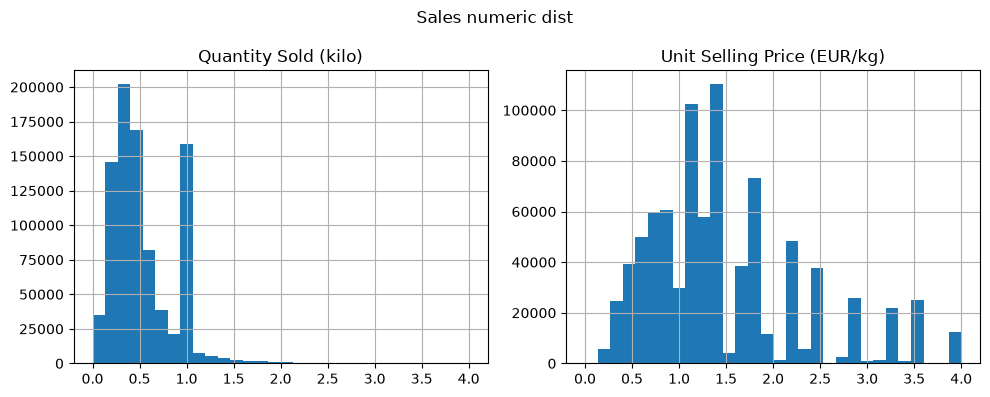

,Category Name,count,proportion
0,Leafy Greens,100,0.40
1,Mushrooms,72,0.29
2,Peppers & Chillies,45,0.18
3,Root & Tuber Vegetables,19,0.08
4,Mediterranean Vegetables,10,0.04
5,Brassicas,5,0.02


,Discount (Yes/No),count,proportion
0,No,831137,0.95
1,Yes,47366,0.05


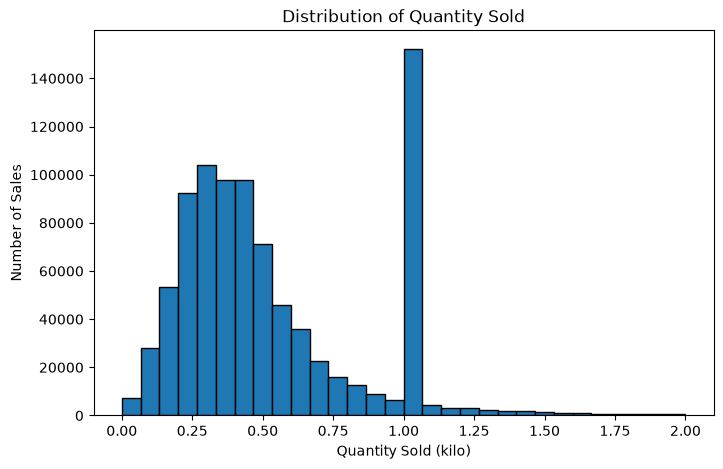

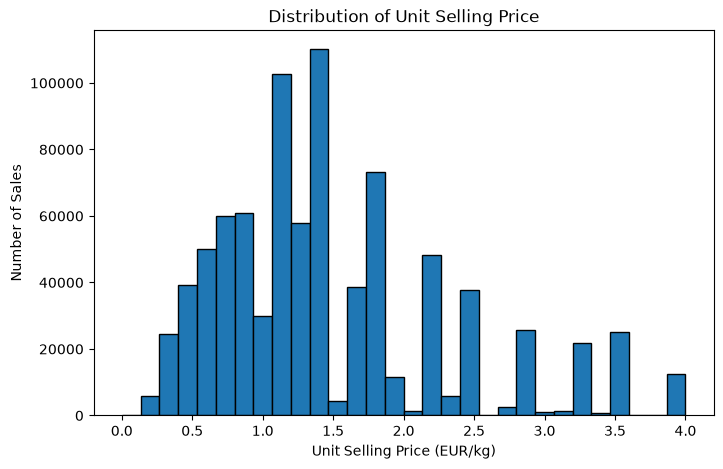

In [ ]:
sales_clean[['Quantity Sold (kilo)','Unit Selling Price (EUR/kg)']].hist(
    bins=30,
    figsize=(10,4),
    range=(0, 4),
)
plt.suptitle('Sales numeric dist')
plt.tight_layout()
plt.show()

display(category_counts)
display(discount_counts)

# If you display graphs separately, you can easily adjust each graph's range of values (Zooming in)
plt.figure(figsize=(8, 5))
 
plt.hist(
    sales_clean['Quantity Sold (kilo)'],
    bins=30,
    range=(0, 2),
    edgecolor='black'
)
 
plt.xlabel('Quantity Sold (kilo)')
plt.ylabel('Number of Sales')
plt.title('Distribution of Quantity Sold')
 
plt.show()

plt.figure(figsize=(8, 5))
 
plt.hist(
    sales_clean['Unit Selling Price (EUR/kg)'],
    bins=30,
    range=(0, 4),
    edgecolor='black'
)
 
plt.xlabel('Unit Selling Price (EUR/kg)')
plt.ylabel('Number of Sales')
plt.title('Distribution of Unit Selling Price')
 
plt.show()

### TASK 11 - Time-series behaviour

Aggregate sales by date. Plot daily quantity sold and daily revenue. Explain why chronological train/test splitting may be better than random splitting for forecasting.


,Date,transactions,quantity_sold_kg,revenue_eur,discount_rate
0,2020-07-01,1001,404.78,626.19,0.03
1,2020-07-02,974,393.68,622.20,0.03
2,2020-07-03,964,386.02,610.49,0.03
3,2020-07-04,1231,483.30,791.09,0.01
4,2020-07-05,1296,516.92,804.88,0.01


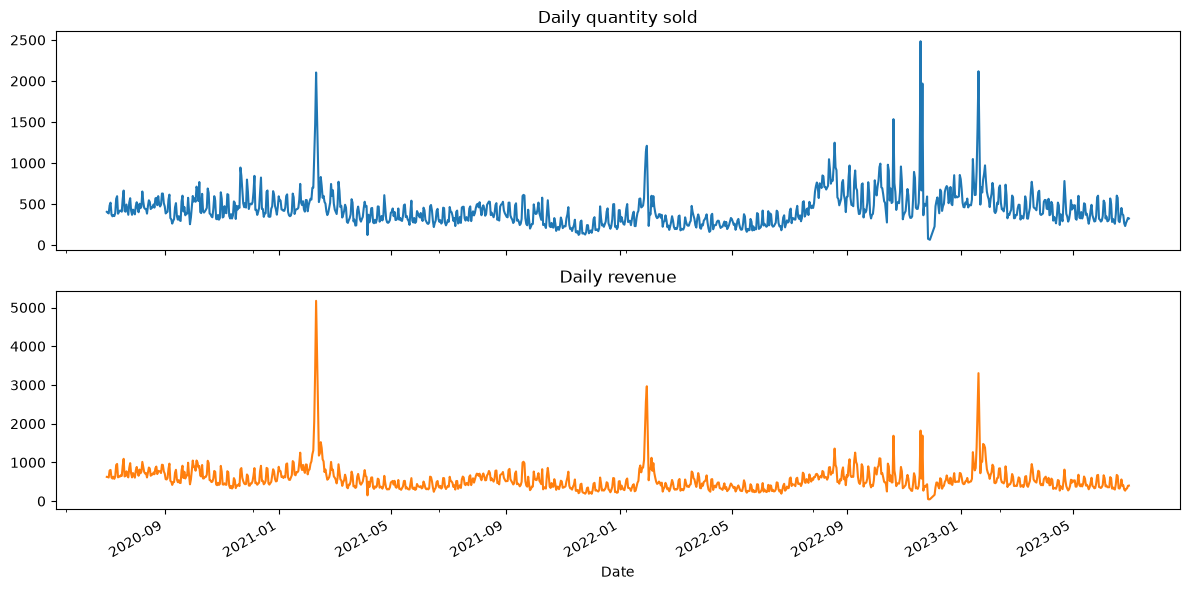

In [30]:
sales_daily = (
    sales_clean
    .assign(revenue=lambda df: df['Quantity Sold (kilo)'] * df['Unit Selling Price (EUR/kg)'])
    .groupby('Date')
    .agg(
        transactions=('Item Code', 'size'),
        quantity_sold_kg=('Quantity Sold (kilo)', 'sum'),
        revenue_eur=('revenue', 'sum'),
        discount_rate=('Discount (Yes/No)', lambda s: (s == 'Yes').mean()),
    )
    .reset_index()
)

display(sales_daily.head())

ax = sales_daily.plot(
    x='Date',
    y=['quantity_sold_kg', 'revenue_eur'],
    subplots=True,
    figsize=(12, 6),
    title=['Daily quantity sold', 'Daily revenue'],
    legend=False,
)
plt.tight_layout()
plt.show()


### TASK 12 - Join the related tables

Join sales to item details, loss rates and wholesale prices. Create revenue, estimated wholesale cost and gross margin columns.


In [31]:
sales_enriched = (
    sales_clean
    .merge(
        items_clean[['Item Code', 'Item Name', 'Category Code', 'Category Name']],
        on='Item Code',
        how='left',
        validate='many_to_one',
    )
    .merge(
        loss_rates_clean[['Item Code', 'Loss Rate (%)']],
        on='Item Code',
        how='left',
        validate='many_to_one',
    )
    .merge(
        wholesale_clean,
        on=['Date', 'Item Code'],
        how='left',
        validate='many_to_one',
    )
)


sales_enriched['Revenue (EUR)'] = (
    sales_enriched['Quantity Sold (kilo)'] * sales_enriched['Unit Selling Price (EUR/kg)']
)
sales_enriched['Estimated Wholesale Cost (EUR)'] = (
    sales_enriched['Quantity Sold (kilo)'] * sales_enriched['Wholesale Price (EUR/kg)']
)
sales_enriched['Gross Margin (EUR)'] = (
    sales_enriched['Revenue (EUR)'] - sales_enriched['Estimated Wholesale Cost (EUR)']
)

print(sales_enriched.shape)
display(sales_enriched.head())
display(sales_enriched.isna().mean().mul(100).round(2).sort_values(ascending=False).head(8).to_frame('missing_percent'))



(877910, 16)


,Date,Time,Item Code,Quantity Sold (kilo),Unit Selling Price (EUR/kg),Sale or Return,Discount (Yes/No),Timestamp,Item Name,Category Code,Category Name,Loss Rate (%),Wholesale Price (EUR/kg),Revenue (EUR),Estimated Wholesale Cost (EUR),Gross Margin (EUR)
0,2020-07-01,09:15:07.924,102900005117056,0.40,1.37,sale,No,2020-07-01 09:15:07.924,Select Red Chillies (Punnet),EU03,Peppers & Chillies,7.08,0.78,0.54,0.31,0.23
1,2020-07-01,09:17:27.295,102900005115960,0.85,0.58,sale,No,2020-07-01 09:17:27.295,Standard Savoy Spinach (Loose),EU01,Leafy Greens,22.27,0.38,0.49,0.32,0.17
2,2020-07-01,09:17:33.905,102900005117056,0.41,1.37,sale,No,2020-07-01 09:17:33.905,Select Red Chillies (Punnet),EU03,Peppers & Chillies,7.08,0.78,0.56,0.32,0.24
3,2020-07-01,09:19:45.450,102900005115823,0.42,1.80,sale,No,2020-07-01 09:19:45.450,Standard Endive (500g pack),EU01,Leafy Greens,14.43,1.27,0.76,0.53,0.22
4,2020-07-01,09:20:23.686,102900005115908,0.54,1.44,sale,No,2020-07-01 09:20:23.686,Standard Radicchio (Tray),EU01,Leafy Greens,13.70,0.83,0.78,0.45,0.33


,missing_percent
Wholesale Price (EUR/kg),0.01
Estimated Wholesale Cost (EUR),0.01
Gross Margin (EUR),0.01
Date,0.00
Time,0.00
Item Code,0.00
Quantity Sold (kilo),0.00
Unit Selling Price (EUR/kg),0.00


### TASK 13 - Prepare simple features

Prepare a feature matrix to predict whether a sale used a discount. Remove identifiers, target leakage and raw text names. One-hot encode categorical columns. Compare the shape before and after encoding.


In [33]:
model_df = sales_enriched.dropna(
    subset=[
        'Category Name',
        'Loss Rate (%)',
        'Wholesale Price (EUR/kg)',
        'Discount (Yes/No)',
    ]
).copy()

model_df['day_of_week'] = model_df['Date'].dt.day_name()
model_df['month'] = model_df['Date'].dt.month

model_df['is_discounted'] = (model_df['Discount (Yes/No)'] == 'Yes').astype(int)

feature_columns = [
    'Quantity Sold (kilo)',
    'Unit Selling Price (EUR/kg)',
    'Wholesale Price (EUR/kg)',
    'Loss Rate (%)',
    'Category Name',
    'Sale or Return',
    'day_of_week',
    'month',
]

X_raw = model_df[feature_columns]
y = model_df['is_discounted']

X_encoded = pd.get_dummies(X_raw, columns=['Category Name', 'Sale or Return', 'day_of_week'], drop_first=False)

display(X_encoded.head())
print('Raw feature shape:', X_raw.shape)
print('Encoded feature shape:', X_encoded.shape)
print('Target positive rate:', round(y.mean(), 3))
display(X_encoded.head())

,Quantity Sold (kilo),Unit Selling Price (EUR/kg),Wholesale Price (EUR/kg),Loss Rate (%),month,Category Name_Brassicas,Category Name_Leafy Greens,Category Name_Mediterranean Vegetables,Category Name_Mushrooms,Category Name_Peppers & Chillies,Category Name_Root & Tuber Vegetables,Sale or Return_sale,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0.40,1.37,0.78,7.08,7,False,False,False,False,True,False,True,False,False,False,False,False,False,True
1,0.85,0.58,0.38,22.27,7,False,True,False,False,False,False,True,False,False,False,False,False,False,True
2,0.41,1.37,0.78,7.08,7,False,False,False,False,True,False,True,False,False,False,False,False,False,True
3,0.42,1.80,1.27,14.43,7,False,True,False,False,False,False,True,False,False,False,False,False,False,True
4,0.54,1.44,0.83,13.70,7,False,True,False,False,False,False,True,False,False,False,False,False,False,True


Raw feature shape: (877838, 8)
Encoded feature shape: (877838, 19)
Target positive rate: 0.054


,Quantity Sold (kilo),Unit Selling Price (EUR/kg),Wholesale Price (EUR/kg),Loss Rate (%),month,Category Name_Brassicas,Category Name_Leafy Greens,Category Name_Mediterranean Vegetables,Category Name_Mushrooms,Category Name_Peppers & Chillies,Category Name_Root & Tuber Vegetables,Sale or Return_sale,day_of_week_Friday,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,0.40,1.37,0.78,7.08,7,False,False,False,False,True,False,True,False,False,False,False,False,False,True
1,0.85,0.58,0.38,22.27,7,False,True,False,False,False,False,True,False,False,False,False,False,False,True
2,0.41,1.37,0.78,7.08,7,False,False,False,False,True,False,True,False,False,False,False,False,False,True
3,0.42,1.80,1.27,14.43,7,False,True,False,False,False,False,True,False,False,False,False,False,False,True
4,0.54,1.44,0.83,13.70,7,False,True,False,False,False,False,True,False,False,False,False,False,False,True


### TASK 14 - Reusable property report

Write `property_report(df)` with column, dtype, semantic guess, missing, unique and example. Run it on all cleaned datasets.


In [34]:
def guess_semantic_type(series):
    name = series.name.lower()
    if 'code' in name or name.endswith('id'):
        return 'nominal identifier'
    if pd.api.types.is_datetime64_any_dtype(series):
        return 'temporal'
    if pd.api.types.is_bool_dtype(series):
        return 'binary nominal'
    if pd.api.types.is_numeric_dtype(series):
        return 'ratio numeric'
    if series.nunique(dropna=True) == 2:
        return 'binary nominal'
    return 'nominal/text'


def property_report(df):
    rows = []
    for column in df.columns:
        s = df[column]
        example = s.dropna().iloc[0] if s.notna().any() else np.nan
        rows.append(
            {
                'column': column,
                'pandas_dtype': str(s.dtype),
                'semantic_guess': guess_semantic_type(s),
                'missing': int(s.isna().sum()),
                'missing_percent': round(float(s.isna().mean() * 100), 2),
                'unique': int(s.nunique(dropna=True)),
                'example': example,
            }
        )
    return pd.DataFrame(rows)


for name, df in {
    'items_clean': items_clean,
    'loss_rates_clean': loss_rates_clean,
    'sales_clean': sales_clean,
    'wholesale_clean': wholesale_clean,
    'sales_enriched': sales_enriched,
}.items():
    print(f'--- {name} ---')
    display(property_report(df))


--- items_clean ---


,column,pandas_dtype,semantic_guess,missing,missing_percent,unique,example
0,Item Code,int64,nominal identifier,0,0.00,251,102900005115168
1,Item Name,str,nominal/text,0,0.00,251,Standard Romaine Lettuce (Loose)
2,Category Code,str,nominal identifier,0,0.00,6,EU01
3,Category Name,str,nominal/text,0,0.00,6,Leafy Greens
4,Original Item Name,str,nominal/text,0,0.00,247,Niushou Shengcai
5,Original Category Code,int64,nominal identifier,0,0.00,6,1011010101
6,Original Category Name,str,nominal/text,0,0.00,6,Flower/Leaf Vegetables


--- loss_rates_clean ---


,column,pandas_dtype,semantic_guess,missing,missing_percent,unique,example
0,Item Code,int64,nominal identifier,0,0.00,251,102900005115168
1,Item Name,str,nominal/text,0,0.00,251,Standard Romaine Lettuce (Loose)
2,Loss Rate (%),float64,ratio numeric,0,0.00,126,4.39
3,Original Item Name,str,nominal/text,0,0.00,247,Niushou Shengcai


--- sales_clean ---


,column,pandas_dtype,semantic_guess,missing,missing_percent,unique,example
0,Date,datetime64[us],temporal,0,0.00,1085,2020-07-01 00:00:00
1,Time,str,nominal/text,0,0.00,849084,09:15:07.924
2,Item Code,int64,nominal identifier,0,0.00,246,102900005117056
3,Quantity Sold (kilo),float64,ratio numeric,0,0.00,2540,0.40
4,Unit Selling Price (EUR/kg),float64,ratio numeric,0,0.00,264,1.37
5,Sale or Return,str,nominal/text,0,0.00,1,sale
6,Discount (Yes/No),str,binary nominal,0,0.00,2,No
7,Timestamp,datetime64[us],temporal,0,0.00,877880,2020-07-01 09:15:07.924000


--- wholesale_clean ---


,column,pandas_dtype,semantic_guess,missing,missing_percent,unique,example
0,Date,datetime64[us],temporal,0,0.00,1091,2020-07-01 00:00:00
1,Item Code,int64,nominal identifier,0,0.00,251,102900005115762
2,Wholesale Price (EUR/kg),float64,ratio numeric,0,0.00,651,0.70


--- sales_enriched ---


,column,pandas_dtype,semantic_guess,missing,missing_percent,unique,example
0,Date,datetime64[us],temporal,0,0.00,1085,2020-07-01 00:00:00
1,Time,str,nominal/text,0,0.00,849084,09:15:07.924
2,Item Code,int64,nominal identifier,0,0.00,246,102900005117056
3,Quantity Sold (kilo),float64,ratio numeric,0,0.00,2540,0.40
4,Unit Selling Price (EUR/kg),float64,ratio numeric,0,0.00,264,1.37
5,Sale or Return,str,nominal/text,0,0.00,1,sale
6,Discount (Yes/No),str,binary nominal,0,0.00,2,No
7,Timestamp,datetime64[us],temporal,0,0.00,877880,2020-07-01 09:15:07.924000
8,Item Name,str,nominal/text,0,0.00,246,Select Red Chillies (Punnet)
9,Category Code,str,nominal identifier,0,0.00,6,EU03


## Exit check

Answer in Markdown:

1. What is the difference between pandas dtype and semantic type?
2. Why is `Item Code` not a useful numeric measurement even though pandas stores it as an integer?
3. Why are quantity, price and revenue ratio variables?
4. Why can random splitting be misleading for time-based sales prediction?
5. Which columns would you exclude from a model, and why?
